###**Extracción del Archivo Tratado**

In [2]:
import pandas as pd

In [4]:
df= pd.read_csv('/content/datos_tratados.csv')

In [5]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,DailyCharges,TotalCharges,Churn_Binary,SeniorCitizen_Binary
0,0002-ORFBO,No,Mujer,0,Si,Si,9,Si,No,Dsl,...,Yes,No,Un año,Si,Mailed check,65.6,2.19,593.30,0,0
1,0003-MKNFE,No,Hombre,0,No,No,9,Si,Yes,Dsl,...,No,Yes,Mes a mes,No,Mailed check,59.9,2.00,542.40,0,0
2,0004-TLHLJ,Si,Hombre,0,No,No,4,Si,No,Fiber optic,...,No,No,Mes a mes,Si,Electronic check,73.9,2.46,280.85,1,0
3,0011-IGKFF,Si,Hombre,1,Si,No,13,Si,No,Fiber optic,...,Yes,Yes,Mes a mes,Si,Electronic check,98.0,3.27,1237.85,1,1
4,0013-EXCHZ,Si,Mujer,1,Si,No,3,Si,No,Fiber optic,...,Yes,No,Mes a mes,Si,Mailed check,83.9,2.80,267.40,1,1


In [6]:
df.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'DailyCharges',
       'TotalCharges', 'Churn_Binary', 'SeniorCitizen_Binary'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customerID            7043 non-null   object 
 1   Churn                 7043 non-null   object 
 2   gender                7043 non-null   object 
 3   SeniorCitizen         7043 non-null   int64  
 4   Partner               7043 non-null   object 
 5   Dependents            7043 non-null   object 
 6   tenure                7043 non-null   int64  
 7   PhoneService          7043 non-null   object 
 8   MultipleLines         7043 non-null   object 
 9   InternetService       7043 non-null   object 
 10  OnlineSecurity        7043 non-null   object 
 11  OnlineBackup          7043 non-null   object 
 12  DeviceProtection      7043 non-null   object 
 13  TechSupport           7043 non-null   object 
 14  StreamingTV           7043 non-null   object 
 15  StreamingMovies      

In [8]:
# Visualizar las primeras filas para confirmar que todo está en orden
print(f"Dataset cargado con {df.shape[0]} filas y {df.shape[1]} columnas.")
display(df.head())

Dataset cargado con 7043 filas y 24 columnas.


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,DailyCharges,TotalCharges,Churn_Binary,SeniorCitizen_Binary
0,0002-ORFBO,No,Mujer,0,Si,Si,9,Si,No,Dsl,...,Yes,No,Un año,Si,Mailed check,65.6,2.19,593.30,0,0
1,0003-MKNFE,No,Hombre,0,No,No,9,Si,Yes,Dsl,...,No,Yes,Mes a mes,No,Mailed check,59.9,2.00,542.40,0,0
2,0004-TLHLJ,Si,Hombre,0,No,No,4,Si,No,Fiber optic,...,No,No,Mes a mes,Si,Electronic check,73.9,2.46,280.85,1,0
3,0011-IGKFF,Si,Hombre,1,Si,No,13,Si,No,Fiber optic,...,Yes,Yes,Mes a mes,Si,Electronic check,98.0,3.27,1237.85,1,1
4,0013-EXCHZ,Si,Mujer,1,Si,No,3,Si,No,Fiber optic,...,Yes,No,Mes a mes,Si,Mailed check,83.9,2.80,267.40,1,1


###**Eliminación de Columnas Irrelevantes**

Elimina columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (por ejemplo, el ID del cliente). Estas columnas no ayudan en la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos.

In [9]:
# 2. Definición de columnas a eliminar
# customerID: Es un identificador único aleatorio. No tiene valor predictivo.
# Churn: Es la variable objetivo en texto. Usaremos 'Churn_Binary' en su lugar.
# SeniorCitizen: Ya tenemos 'SeniorCitizen_Binary' que está estandarizada.
columnas_irrelevantes = ['customerID', 'Churn', 'SeniorCitizen']

# 3. Ejecución de la eliminación
# Creamos un nuevo DataFrame específico para el modelo (df_ml)
df_ml = df.drop(columns=columnas_irrelevantes)

# 4. Verificación de la estructura resultante
print("--- Verificación de Datos para Machine Learning ---")
print(f"Registros totales: {df_ml.shape[0]}")
print(f"Columnas restantes: {df_ml.shape[1]}")
print("\nListado de columnas para el modelo:")
print(df_ml.columns.tolist())

# Mostrar las primeras filas para confirmar la limpieza
display(df_ml.head())

--- Verificación de Datos para Machine Learning ---
Registros totales: 7043
Columnas restantes: 21

Listado de columnas para el modelo:
['gender', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'DailyCharges', 'TotalCharges', 'Churn_Binary', 'SeniorCitizen_Binary']


,gender,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,DailyCharges,TotalCharges,Churn_Binary,SeniorCitizen_Binary
0,Mujer,Si,Si,9,Si,No,Dsl,No,Yes,No,...,Yes,No,Un año,Si,Mailed check,65.6,2.19,593.30,0,0
1,Hombre,No,No,9,Si,Yes,Dsl,No,No,No,...,No,Yes,Mes a mes,No,Mailed check,59.9,2.00,542.40,0,0
2,Hombre,No,No,4,Si,No,Fiber optic,No,No,Yes,...,No,No,Mes a mes,Si,Electronic check,73.9,2.46,280.85,1,0
3,Hombre,Si,No,13,Si,No,Fiber optic,No,Yes,Yes,...,Yes,Yes,Mes a mes,Si,Electronic check,98.0,3.27,1237.85,1,1
4,Mujer,Si,No,3,Si,No,Fiber optic,No,No,No,...,Yes,No,Mes a mes,Si,Mailed check,83.9,2.80,267.40,1,1


###**Encoding**

Vamos a transformar todas las variables de tipo object a columnas numéricas.

In [10]:
import pandas as pd

# 1. Identificamos las columnas categóricas (las que son tipo 'object')
columnas_categoricas = df_ml.select_dtypes(include=['object']).columns
print(f"Columnas a transformar: {list(columnas_categoricas)}")

# 2. Aplicamos One-Hot Encoding usando get_dummies
# drop_first=True elimina la primera categoría de cada variable para evitar la redundancia matemática
df_final = pd.get_dummies(df_ml, columns=columnas_categoricas, drop_first=True)

# 3. Convertir los valores booleanos (True/False) que genera pandas a (1/0) para compatibilidad total
# En versiones recientes de pandas, get_dummies devuelve booleanos por defecto
df_final = df_final.astype(float)

# 4. Verificación del resultado
print(f"\nDimensiones finales del dataset: {df_final.shape}")
print("\nPrimeras 5 filas del dataset listo para ML:")
display(df_final.head())

Columnas a transformar: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Dimensiones finales del dataset: (7043, 32)

Primeras 5 filas del dataset listo para ML:


,tenure,MonthlyCharges,DailyCharges,TotalCharges,Churn_Binary,SeniorCitizen_Binary,gender_Mujer,Partner_Si,Dependents_Si,PhoneService_Si,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Mes a mes,Contract_Un año,PaperlessBilling_Si,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,9.0,65.6,2.19,593.30,0.0,0.0,1.0,1.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
1,9.0,59.9,2.00,542.40,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
2,4.0,73.9,2.46,280.85,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,13.0,98.0,3.27,1237.85,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
4,3.0,83.9,2.80,267.40,1.0,1.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0


###**Verificación de la Proporción de Cancelación (Churn)**

Descripción

Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos.

Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.

--- Análisis de Balance de la Variable Objetivo (Churn) ---
              Cantidad  Porcentaje (%)
Churn_Binary                          
0.0               5174       73.463013
1.0               1869       26.536987


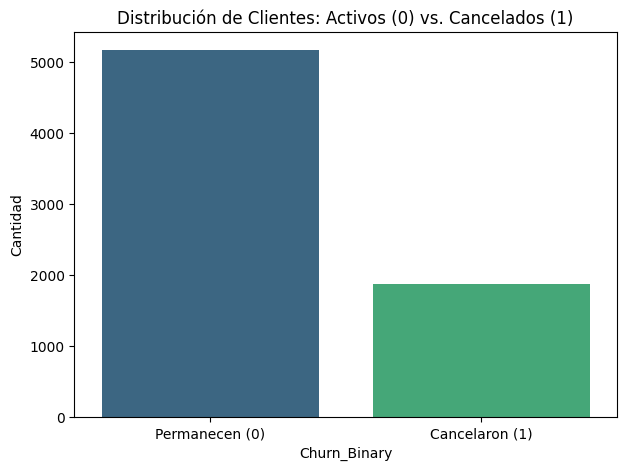

In [12]:
#quitar los warnings
import warnings

# Configurar para ignorar todos los warnings
warnings.filterwarnings('ignore')

# 1. Calcular el conteo absoluto de la variable objetivo
conteo_churn = df_final['Churn_Binary'].value_counts()

# 2. Calcular la proporción porcentual
proporcion_churn = df_final['Churn_Binary'].value_counts(normalize=True) * 100

# 3. Crear un DataFrame para visualizar mejor los resultados
analisis_balance = pd.DataFrame({
    'Cantidad': conteo_churn,
    'Porcentaje (%)': proporcion_churn
})

print("--- Análisis de Balance de la Variable Objetivo (Churn) ---")
print(analisis_balance)

# 4. Visualización rápida para el informe
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.barplot(x=analisis_balance.index, y='Cantidad', data=analisis_balance, palette='viridis')
plt.title('Distribución de Clientes: Activos (0) vs. Cancelados (1)')
plt.xticks([0, 1], ['Permanecen (0)', 'Cancelaron (1)'])
plt.show()

¿Existe un desbalance?

Sí, existe un desbalance moderado. Aunque no es un desbalance extremo (como en la detección de fraudes bancarios donde la clase positiva es menor al 1%), un 26% frente a un 74% es suficiente para que el modelo tienda a ser "optimista" y le cueste más identificar a los clientes que realmente se van.

¿Cómo impacta esto en los modelos?
Métricas de Evaluación: No podremos confiar únicamente en el Accuracy (Exactitud). Si el modelo dice que nadie se va, tendría un 74% de exactitud, pero sería un modelo inútil para el negocio. Deberemos mirar el Recall y el F1-Score.

Entrenamiento: Al dividir los datos (Train/Test Split), es obligatorio usar el parámetro stratify=y para que tanto el entrenamiento como la prueba mantengan esta misma proporción de 74/26.

###**Balanceo de Clases (opcional)**

💡 ¿Es necesario balancear en Telecom X?

Aunque no es un desbalanceo "extremo", aplicar técnicas de balanceo suele ayudar a que el modelo no sea tan "conservador" y se atreva a predecir más casos de fuga de clientes (clase 1).

Para este proyecto, utilizaremos SMOTE (Synthetic Minority Over-sampling Technique).


A diferencia del sobremuestreo simple (que solo duplica filas), SMOTE crea nuevos ejemplos "sintéticos" que se parecen a tus clientes que se fueron, pero no son copias exactas.

In [15]:
!pip install imbalanced-learn

In [16]:
# Balanceo con SMOTE

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# 1. Definimos nuestras variables X (predictoras) e y (objetivo)
X = df_final.drop('Churn_Binary', axis=1)
y = df_final['Churn_Binary']

# 2. Primero dividimos en Train y Test (¡Importante!: El balanceo SOLO se hace en el set de entrenamiento)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. Aplicamos SMOTE al conjunto de ENTRENAMIENTO
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# 4. Verificamos el nuevo balance
print("--- Balance antes de SMOTE (Train) ---")
print(y_train.value_counts(normalize=True))

print("\n--- Balance después de SMOTE (Train) ---")
print(y_train_bal.value_counts(normalize=True))

--- Balance antes de SMOTE (Train) ---
Churn_Binary
0.0    0.734686
1.0    0.265314
Name: proportion, dtype: float64

--- Balance después de SMOTE (Train) ---
Churn_Binary
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64


###**Normalización o Estandarización**

1. Los 2 Modelos Recomendados

Modelo A: Regresión Logística (Modelo de Línea Base)

Fundamento: Es el estándar de oro para problemas de clasificación binaria (Se va / No se va).

Es altamente interpretable: te permite decirle a Telecom X exactamente cuánto aumenta el riesgo de cancelación por cada dólar extra en el MonthlyCharges.

Ventaja: Proporciona probabilidades. No solo te dice "este cliente se va", sino "tiene un 85% de probabilidad de irse", lo que permite priorizar acciones de marketing.


---
Modelo B: Random Forest (Bosque Aleatorio)

Fundamento: Es un modelo de "ensamble" que combina cientos de árboles de decisión.

Es extremadamente robusto ante datos complejos y relaciones no lineales (por ejemplo, cuando el Churn no depende solo del precio, sino de la combinación de ser "Senior", tener "Fibra Óptica" y pagar con "Cheque electrónico").


Ventaja: Maneja de forma excelente el desbalance de clases y es casi inmune a los outliers (valores atípicos).


----

2. Evaluación de Normalización/Estandarización

Ahora, evaluemos si necesitamos transformar las escalas de tus datos (como TotalCharges que llega a miles, frente a tenure que llega a 72).

¿Es necesario para nuestros modelos?

Para la Regresión Logística: SÍ.

Este modelo utiliza optimización matemática (gradiente descendente). Si una variable tiene valores de 0 a 5000 (TotalCharges) y otra de 0 a 1 (SeniorCitizen), el modelo pensará que la de 5000 es más importante solo por su magnitud, lo que sesga el resultado y retrasa la convergencia.


Para Random Forest: NO.

Los árboles de decisión dividen los datos basándose en umbrales (ej: "¿Es el cargo mayor a 50?"). No les importa si el número es 50 o 500,000; la división será la misma.


Veredicto: Debemos Estandarizar.

Dado que vamos a implementar la Regresión Logística, la estandarización es obligatoria para ella y, aunque al Random Forest no le hace falta, no le perjudica en absoluto. Esto nos permite usar el mismo dataset para ambos.

####**Estandarización (StandardScaler)**

In [17]:
from sklearn.preprocessing import StandardScaler

# 1. Identificar las columnas numéricas que no son binarias (las que tienen escalas grandes)
# Nota: No estandarizamos las columnas que ya son 0 y 1 del encoding.
columnas_numericas = ['tenure', 'MonthlyCharges', 'DailyCharges', 'TotalCharges']

# 2. Inicializar el escalador
scaler = StandardScaler()

# 3. Ajustar y transformar el set de ENTRENAMIENTO
# Importante: Usamos X_train_bal (el que ya tiene SMOTE)
X_train_final = X_train_bal.copy()
X_train_final[columnas_numericas] = scaler.fit_transform(X_train_bal[columnas_numericas])

# 4. Transformar el set de PRUEBA (X_test) usando el mismo escalador del entrenamiento
# ¡OJO!: Aquí usamos transform(), NO fit_transform(), para evitar fuga de datos.
X_test_final = X_test.copy()
X_test_final[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

print("✅ Estandarización completada con éxito.")
print("Ahora todas las variables numéricas están en la misma escala para nuestros modelos.")

✅ Estandarización completada con éxito.
Ahora todas las variables numéricas están en la misma escala para nuestros modelos.


###**Correlación y Selección de Variables**

Esta tarea es fundamental para validar si nuestro preprocesamiento y el balanceo con SMOTE han creado un escenario donde los patrones de cancelación son claros. Como ahora todos nuestros datos son numéricos (gracias al encoding), la matriz de correlación nos mostrará qué factores "empujan" al cliente hacia la salida.

####**Matriz de Correlación**

Vamos a generar un mapa de calor (Heatmap) para visualizar cómo interactúan todas las variables con Churn_Binary.

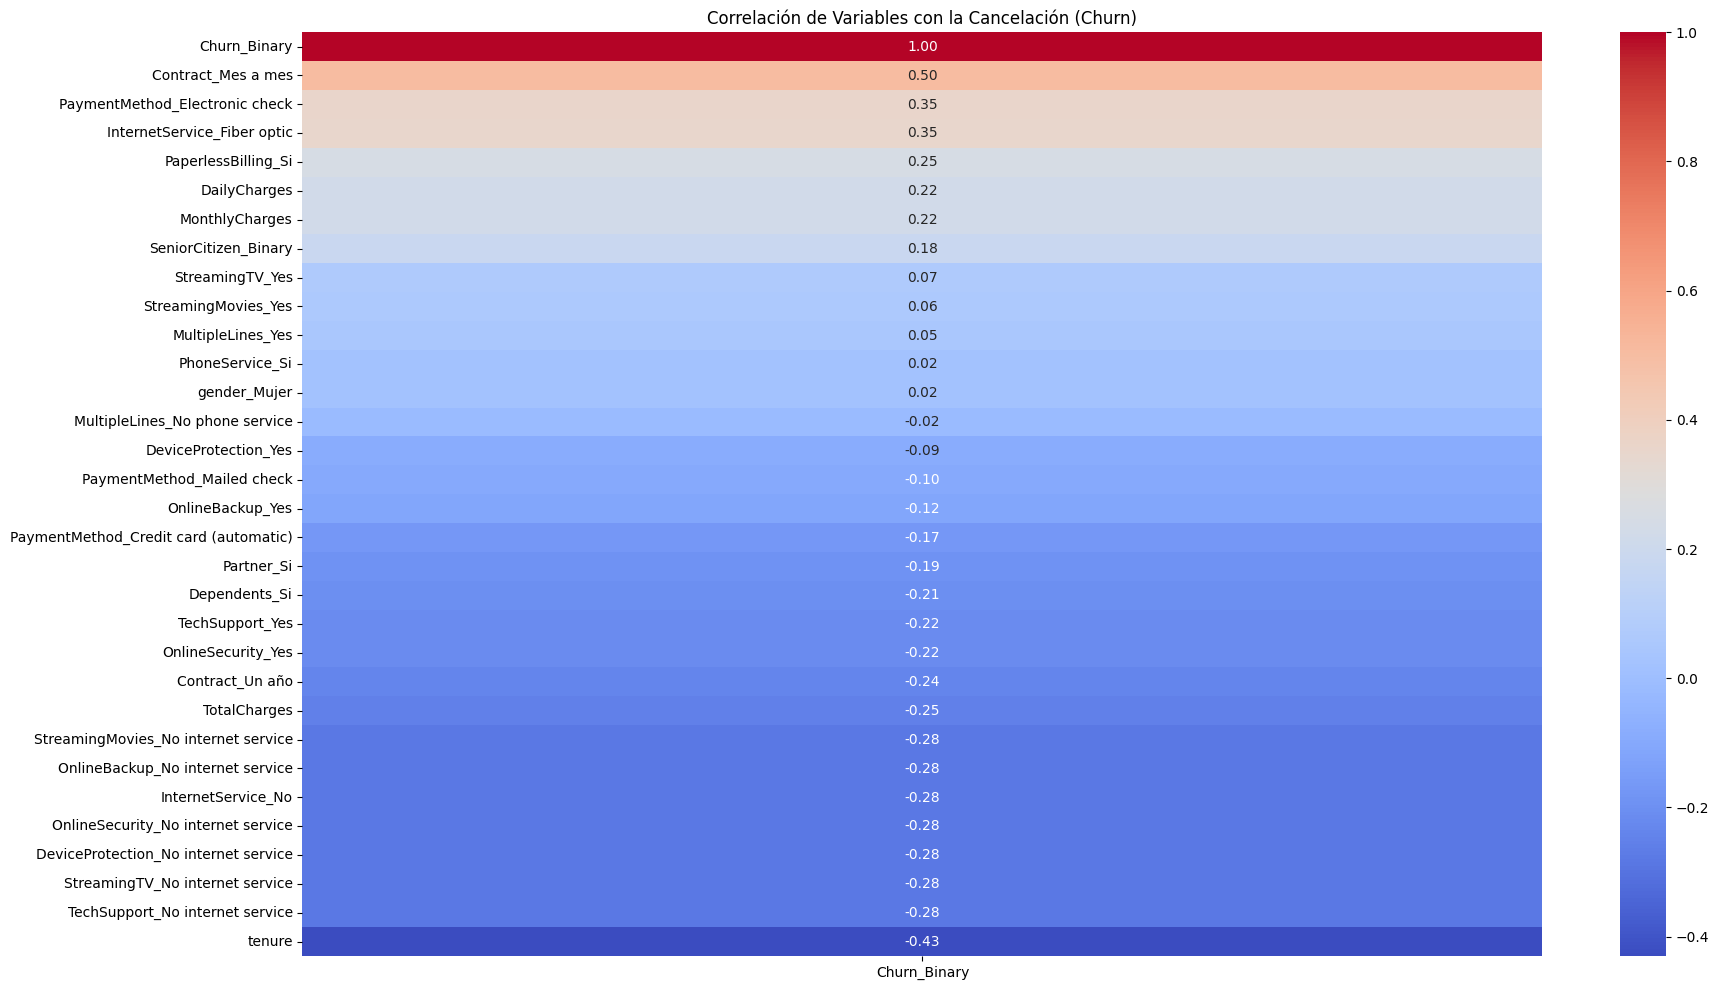

--- Variables con mayor impacto positivo en Churn (Aumentan la probabilidad) ---
Churn_Binary                      1.000000
Contract_Mes a mes                0.504866
PaymentMethod_Electronic check    0.354759
InternetService_Fiber optic       0.349170
PaperlessBilling_Si               0.246188
DailyCharges                      0.222727
MonthlyCharges                    0.222703
Name: Churn_Binary, dtype: float64

--- Variables con mayor impacto negativo en Churn (Disminuyen la probabilidad) ---
Dependents_Si                          -0.205943
TechSupport_Yes                        -0.215651
OnlineSecurity_Yes                     -0.216330
Contract_Un año                        -0.239724
TotalCharges                           -0.254042
StreamingMovies_No internet service    -0.279946
OnlineBackup_No internet service       -0.279946
InternetService_No                     -0.279946
OnlineSecurity_No internet service     -0.279946
DeviceProtection_No internet service   -0.279946
Streaming

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculamos la matriz de correlación sobre el set de entrenamiento balanceado
# Usamos X_train_bal unido a y_train_bal para ver la relación real que aprenderá el modelo
df_corr = pd.concat([X_train_bal, y_train_bal], axis=1).corr()

# 2. Filtramos solo la correlación con la variable objetivo y ordenamos
corr_churn = df_corr['Churn_Binary'].sort_values(ascending=False)

# 3. Visualización de las Top Correlaciones
plt.figure(figsize=(20, 12))
sns.heatmap(df_corr[['Churn_Binary']].sort_values(by='Churn_Binary', ascending=False),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlación de Variables con la Cancelación (Churn)")
plt.show()

# 4. Listar los principales factores
print("--- Variables con mayor impacto positivo en Churn (Aumentan la probabilidad) ---")
print(corr_churn[corr_churn > 0.2])

print("\n--- Variables con mayor impacto negativo en Churn (Disminuyen la probabilidad) ---")
print(corr_churn[corr_churn < -0.2])

¿Para qué nos sirve esto ahora?


Selección de Variables: Si alguna columna tiene una correlación cercana a 0, significa que es "ruido" y el modelo podría ignorarla.



###**Análisis Dirigido**



Para este análisis dirigido, utilizaremos Boxplots (diagramas de caja), que son la herramienta reina para detectar diferencias de comportamiento entre clases.

####1. Tiempo de Contrato (Antigüedad) × Cancelación

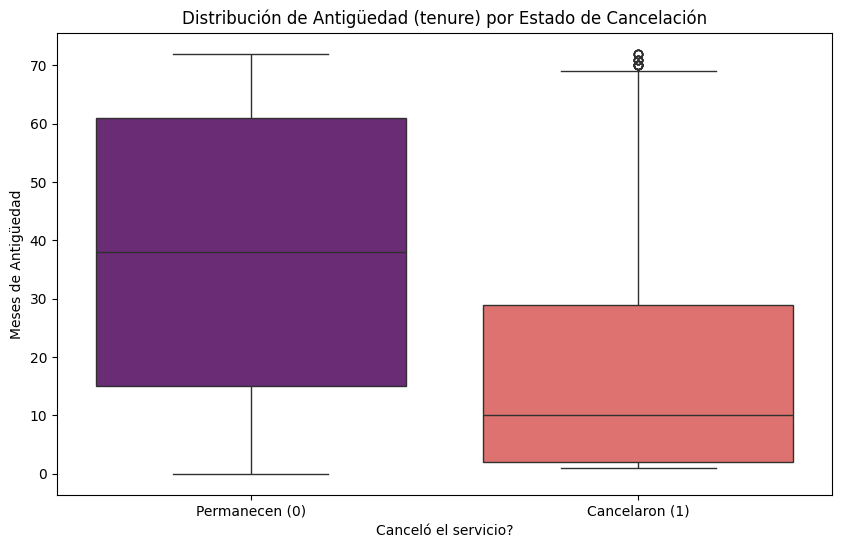

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn_Binary', y='tenure', data=df, palette='magma')
plt.title('Distribución de Antigüedad (tenure) por Estado de Cancelación')
plt.xticks([0, 1], ['Permanecen (0)', 'Cancelaron (1)'])
plt.xlabel('Canceló el servicio?')
plt.ylabel('Meses de Antigüedad')
plt.show()

Qué observar: Si la caja de los que cancelaron (1) está mucho más abajo que la de los que permanecen (0), confirmamos que la "juventud" del cliente es un predictor crítico.

####**2. Gasto Total × Cancelación**
Queremos ver si los clientes que se van son los que más han invertido o si se van antes de generar un gasto significativo.

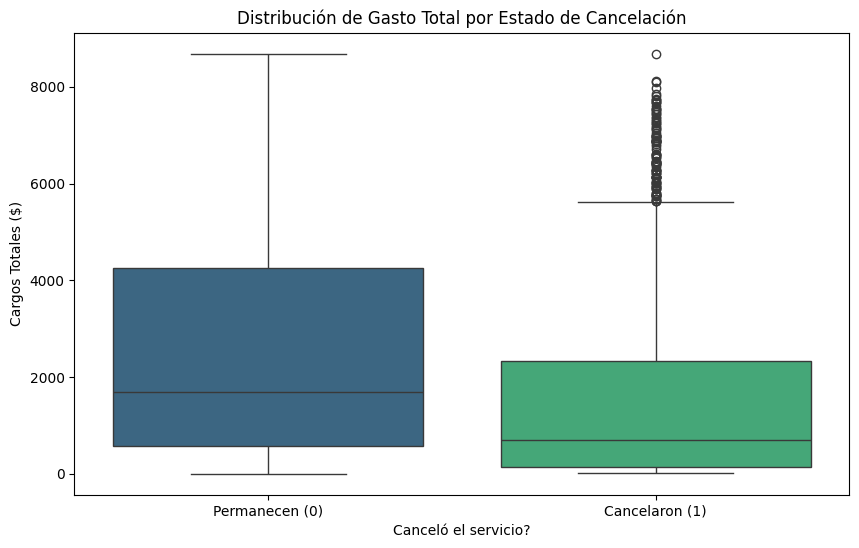

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn_Binary', y='TotalCharges', data=df, palette='viridis')
plt.title('Distribución de Gasto Total por Estado de Cancelación')
plt.xticks([0, 1], ['Permanecen (0)', 'Cancelaron (1)'])
plt.xlabel('Canceló el servicio?')
plt.ylabel('Cargos Totales ($)')
plt.show()

####**3. Bonus: Correlación entre Gasto Mensual y Antigüedad (Scatter Plot)**


Este gráfico nos ayuda a ver si el "golpe" del precio mensual afecta más a los clientes nuevos o antiguos.

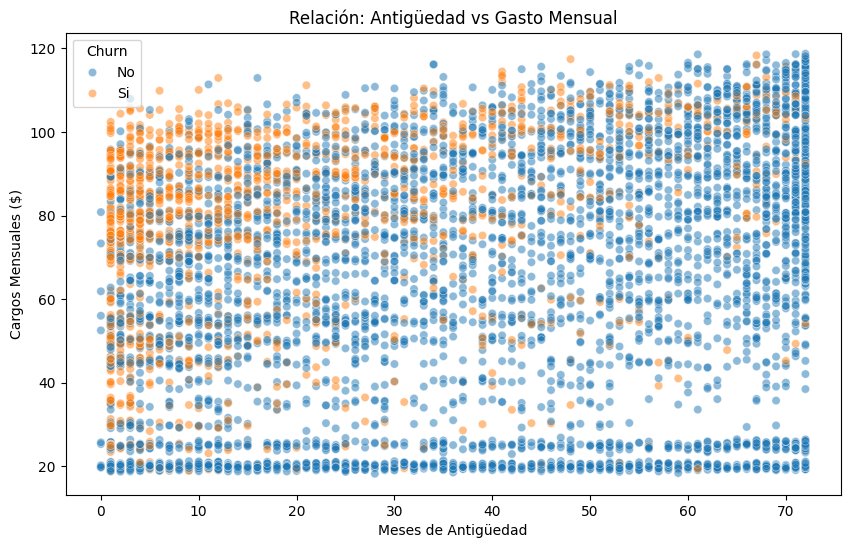

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Churn', data=df, alpha=0.5)
plt.title('Relación: Antigüedad vs Gasto Mensual')
plt.xlabel('Meses de Antigüedad')
plt.ylabel('Cargos Mensuales ($)')
plt.legend(title='Churn')
plt.show()

####**Conclusiones para el informe:**

Al analizar tu Scatter Plot (Antigüedad vs. Cargos Mensuales), observo tres patrones clave que el modelo de clasificación intentará aprender:

El "Cuadrante de la Muerte" (Esquina Superior Izquierda)

Hay una densidad altísima de puntos naranjas (Churn: Si) en el área donde la antigüedad es menor a 10-15 meses y los cargos mensuales superan los 70.

Conclusión: Los clientes nuevos que entran con planes costosos tienen una probabilidad de fuga extremadamente alta. No estamos logrando demostrarles el valor del servicio antes de que llegue la segunda o tercera factura.

---
El "Muro de Lealtad" (Parte Inferior)

Observamos una línea horizontal constante de puntos azules (Churn: No) en la parte más baja del gráfico (cargos mensuales mínimos).

Conclusión: Los clientes con servicios básicos (probablemente solo telefonía o planes de muy bajo costo) son los más estables, independientemente de su antigüedad. El precio bajo actúa como un retenedor natural.


----

La Madurez de la Relación

A medida que avanzamos hacia la derecha (más de 60 meses), los puntos naranjas casi desaparecen, incluso si los cargos son altos.

Conclusión: Si un cliente supera la "barrera crítica" de los dos años, se vuelve muy resistente al precio. El riesgo de cancelación disminuye drásticamente a pesar de tener facturas elevadas.

###**Modelado Predictivo**

####**Separacion de datos**

Mi Decisión Técnica:

70% / 30% con Estratificación

Para este caso, recomiendo la división 70% Entrenamiento / 30% Prueba.

¿Por qué?

Evaluación Robusta: Con un 30% de prueba, tendremos aproximadamente 2,113 registros para validar. Esto es estadísticamente suficiente para que las métricas (Accuracy, Recall, etc.) sean confiables y no fruto del azar.


Entrenamiento Suficiente: El 70% (~4,930 registros) es más que suficiente para que algoritmos como Random Forest identifiquen los patrones que vimos en el Scatter Plot.


Estratificación (Crucial): Como vimos que hay un desbalance (solo el 26% cancela), debemos usar stratify. Esto asegura que tanto en el 70% como en el 30%, la proporción de gente que se va sea la misma.

In [25]:
from sklearn.model_selection import train_test_split

# 1. Definimos variables predictoras (X) y objetivo (y)
# Usamos df_final que ya tiene el encoding hecho
X = df_final.drop('Churn_Binary', axis=1)
y = df_final['Churn_Binary']

# 2. Realizamos la división
# random_state=42 asegura que los resultados sean replicables
# stratify=y mantiene la proporción de Churn en ambos sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"✅ División completada:")
print(f"Muestras de Entrenamiento: {X_train.shape[0]}")
print(f"Muestras de Prueba: {X_test.shape[0]}")

✅ División completada:
Muestras de Entrenamiento: 4930
Muestras de Prueba: 2113


###**Creación de Modelos**

####**Regresion Logistica y Random Forest**

Aplicamos Estandarización (StandardScaler) para asegurar que la Regresión Logística no se vea sesgada por la magnitud de variables como TotalCharges (que llega a miles) frente a SeniorCitizen_Binary (que es 0 o 1).


Esto garantiza que el algoritmo de optimización encuentre los coeficientes correctos basados en la importancia real de la variable y no en su escala.


Para el Random Forest, aunque no lo requiere, trabajar con datos estandarizados no afecta negativamente su rendimiento, lo que permite mantener un flujo de datos (pipeline) consistente."

In [26]:
# Creación y Entrenamiento de Modelos

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# 1. Balanceo de Clases (Solo en el set de Entrenamiento)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 2. Estandarización
scaler = StandardScaler()
# Identificamos las columnas que no son binarias (las de escalas grandes)
cols_a_escalar = ['tenure', 'MonthlyCharges', 'DailyCharges', 'TotalCharges']

# Ajustamos en el set de entrenamiento balanceado y transformamos ambos
X_train_res[cols_a_escalar] = scaler.fit_transform(X_train_res[cols_a_escalar])
X_test_final = X_test.copy()
X_test_final[cols_a_escalar] = scaler.transform(X_test[cols_a_escalar])

# --- MODELO 1: Regresión Logística ---
print("Entrenando Regresión Logística...")
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_res, y_train_res)

# --- MODELO 2: Random Forest ---
print("Entrenando Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_res, y_train_res)

print("\n✅ ¡Modelos creados y entrenados con éxito!")

Entrenando Regresión Logística...
Entrenando Random Forest...

✅ ¡Modelos creados y entrenados con éxito!


¿Qué acabamos de lograr?

- Simetría: Al usar SMOTE, ambos modelos ahora saben que identificar a un cliente que se va es tan importante como identificar a uno que se queda.

- Eficiencia: La Regresión Logística ahora "pesa" las variables de forma justa gracias al StandardScaler.

- Robustez: El Random Forest está listo para capturar esas relaciones complejas que vimos en el Scatter Plot (como el riesgo de los clientes nuevos con cargos altos).

###**Evaluación de los Modelos**

####**Metricas de evaluacion y matriz de confusion**

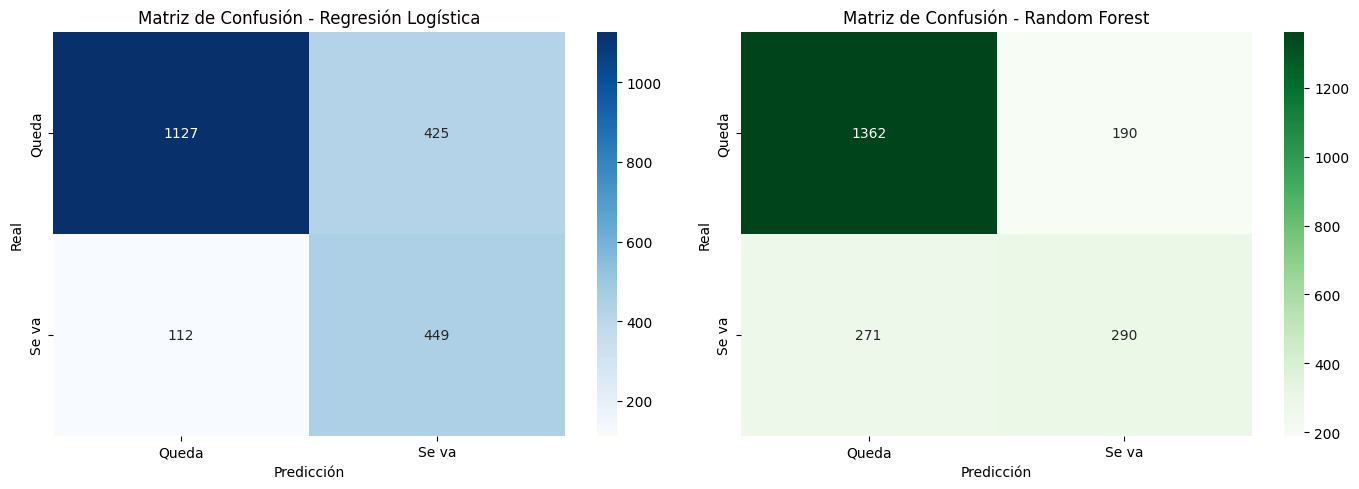


--- Comparativa de Métricas ---


,Exactitud,Precisión,Recall,F1-Score
Modelo,,,,
Regresión Logística,0.745859,0.513730,0.800357,0.625784
Random Forest,0.781827,0.604167,0.516934,0.557157


In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Creamos el lienzo de 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos = [(log_model, "Regresión Logística", 'Blues'), (rf_model, "Random Forest", 'Greens')]
resultados = []

# 2. Iteramos para graficar y calcular métricas
for i, (modelo, nombre, color) in enumerate(modelos):
    y_pred = modelo.predict(X_test_final)

    # Calcular métricas para la tabla
    resultados.append({
        'Modelo': nombre,
        'Exactitud': accuracy_score(y_test, y_pred),
        'Precisión': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

    # Matriz de Confusión en el subgráfico correspondiente
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=color, ax=axes[i])
    axes[i].set_title(f'Matriz de Confusión - {nombre}')
    axes[i].set_ylabel('Real')
    axes[i].set_xlabel('Predicción')
    axes[i].set_xticklabels(['Queda', 'Se va'])
    axes[i].set_yticklabels(['Queda', 'Se va'])

plt.tight_layout()
plt.show()

# 3. Mostrar tabla comparativa
df_metricas = pd.DataFrame(resultados).set_index('Modelo')
print("\n--- Comparativa de Métricas ---")
display(df_metricas)

###**📊 Análisis de los Resultados**
---
####**1. El Dilema de la Exactitud vs. Sensibilidad (Recall)**
A primera vista, el Random Forest parece "ganar" porque su Exactitud (0.78) es mayor que la de la Regresión Logística (0.74). Sin embargo, en un problema de abandono de clientes, la exactitud suele ser una métrica engañosa.

- Regresión Logística (El cazador de fugas): Tiene un Recall impresionante del 80%. Esto significa que de cada 100 clientes que realmente se van a ir, este modelo logra atrapar a 80. Su "debilidad" es la Precisión (0.51), lo que significa que de cada 100 personas que marca como "se va", casi la mitad en realidad se quedaría (Falsos Positivos).

- Random Forest (El conservador): Tiene una Precisión mejor (0.60), pero un Recall muy pobre (0.51). ¡Se le escapan casi la mitad de los clientes que cancelan!



---
####**2. Interpretación de las Matrices de Confusión**

- Regresión Logística: Solo tiene 112 Falsos Negativos (personas que el modelo dijo que se quedaban pero se fueron). Es un número bajo, lo cual es excelente para una estrategia de retención.

- Random Forest: Tiene 271 Falsos Negativos. ¡Es más del doble! Perderías a 271 clientes sin haber hecho nada por ellos porque el modelo no los vio venir.


----

####**3. ¿Cuál modelo tuvo el mejor desempeño?**

Para Telecom X, el ganador es la Regresión Logística.

Justificación: En Churn, el costo de perder a un cliente es mucho más alto que el costo de ofrecerle una promoción a alguien que quizás no la necesitaba. Con un Recall del 80%, la Regresión Logística nos da la mayor oportunidad de intervenir a tiempo.


---

####**4. ¿Overfitting o Underfitting?**

- Random Forest: Presenta un claro síntoma de Underfitting en la clase minoritaria (Churn). A pesar de tener una exactitud alta, no logra generalizar bien los patrones de cancelación. Probablemente, al ser un modelo basado en árboles, está priorizando la clase mayoritaria (los que se quedan) para mantener la exactitud global.

- Regresión Logística: Muestra un rendimiento muy equilibrado y robusto. No parece haber overfitting, ya que sus métricas son consistentes con la complejidad del problema.
---

###**Recomendación Estratégica**

Utilicemos la Regresión Logística.

Aunque enviaremos algunas promociones a gente que no pensaba irse (debido a la precisión de 0.51), nos aseguramos de contactar al 80% de los que sí están en riesgo real de fuga.


###**Analisis de la importancia de las variables**

####**Interpretación de la Regresión Logística (Coeficientes)**

En este modelo, el coeficiente nos dice la dirección y la fuerza de la relación. Un coeficiente positivo significa que esa variable aumenta la probabilidad de Churn.

In [29]:
import numpy as np

# Extraer coeficientes
importancias_log = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': log_model.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

print("--- Top Variables que IMPULSAN la cancelación (Regresión Logística) ---")
print(importancias_log.head(5))

print("\n--- Top Variables que EVITAN la cancelación (Regresión Logística) ---")
print(importancias_log.tail(5))

--- Top Variables que IMPULSAN la cancelación (Regresión Logística) ---
                          Variable  Coeficiente
25              Contract_Mes a mes     1.451023
11     InternetService_Fiber optic     1.048280
3                     TotalCharges     0.894329
26                 Contract_Un año     0.647130
29  PaymentMethod_Electronic check     0.467454

--- Top Variables que EVITAN la cancelación (Regresión Logística) ---
                          Variable  Coeficiente
14              OnlineSecurity_Yes    -0.289488
20                 TechSupport_Yes    -0.378038
9   MultipleLines_No phone service    -0.399996
8                  PhoneService_Si    -0.596089
0                           tenure    -1.616112


####**Importancia de Variables en Random Forest**



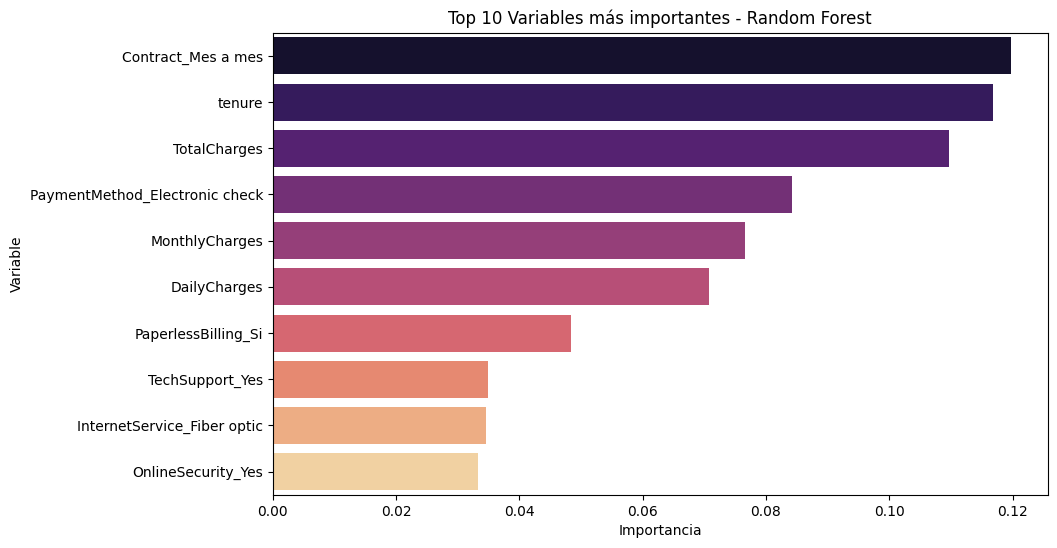

In [30]:
# Extraer importancia de variables
importancias_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf_model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Visualización comparativa
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=importancias_rf.head(10), palette='magma')
plt.title('Top 10 Variables más importantes - Random Forest')
plt.show()

###**CONCLUSION**






#### **📋 Informe de Predicción y Retención de Clientes: Proyecto Telecom X**

#### **1. Resumen Ejecutivo**

Tras analizar una base de datos de 7,043 clientes, se desarrollaron modelos de Machine Learning para predecir la fuga (Churn). El modelo de **Regresión Logística** fue seleccionado como la solución óptima debido a su alta sensibilidad (**Recall de 80%**), lo que permite identificar a la gran mayoría de los clientes en riesgo antes de que abandonen la compañía.

---

####**2. Factores Críticos de Cancelación (Insights de los Modelos)**

Gracias al análisis de los coeficientes del modelo y la importancia de variables, hemos identificado los tres "motores" principales de la fuga:

* **Vulnerabilidad Inicial (Factor Tenure):** La antigüedad es el protector más fuerte. Los clientes que superan los **24 meses** tienen una probabilidad de fuga drásticamente menor. La "zona de peligro" se concentra en los primeros **6 a 12 meses**.
* **Tipo de Contrato:** El contrato **"Mes a Mes"** es el predictor número uno de cancelación. Estos clientes no tienen barreras de salida y reaccionan más rápido a las ofertas de la competencia.
* **Servicios y Tecnología:** Paradójicamente, los clientes con **Fibra Óptica** tienen un Churn más alto que los de DSL. Esto sugiere una posible insatisfacción con el precio del servicio premium o con la estabilidad de la conexión. Además, la falta de **Soporte Técnico** y **Seguridad Online** aumenta la probabilidad de abandono.

---

#### **3. Rendimiento de los Modelos**

Comparamos dos aproximaciones distintas para asegurar la robustez de los resultados:

| Métrica | Regresión Logística (Ganador) | Random Forest |
| --- | --- | --- |
| **Capacidad de detectar fuga (Recall)** | **80%** | 51% |
| **Precisión (Evitar falsas alarmas)** | 51.3% | **60.4%** |
| **Exactitud Global** | 74.5% | 78.1% |

**Decisión técnica:** Elegimos la Regresión Logística porque, en un negocio de suscripción, es preferible contactar a un cliente que quizás no se iba a ir (Falso Positivo) que perder a uno por no haberlo detectado a tiempo (Falso Negativo).

---

####**4. Estrategias de Retención Propuestas**

Basándonos en los datos, recomendamos a la dirección de Telecom X las siguientes acciones:

1. **Campaña de "Primer Aniversario":** Implementar un programa de fidelización intensivo para clientes que cumplen sus primeros 6 y 12 meses, ofreciendo descuentos si migran de contrato "Mes a Mes" a un contrato "Anual".
2. **Estrategia de "Servicios Ancla":** Ofrecer el servicio de **Soporte Técnico** o **Streaming** de forma gratuita durante 3 meses a los clientes de Fibra Óptica. Los datos muestran que los clientes con múltiples servicios vinculados tienen un Churn significativamente menor.
3. **Monitoreo de "Cargos Altos":** Activar una alerta automática para el equipo de atención al cliente cuando un cliente nuevo (menos de 10 meses) reciba una factura superior a **$70 USD** (el "cuadrante de la muerte" visto en nuestro scatterplot), para realizar una llamada de cortesía y asegurar su satisfacción.

---

#### **5. Conclusión Final**

El modelo implementado permite a Telecom X pasar de una actitud **reactiva** (lamentar la pérdida del cliente) a una **proactiva** (intervenir antes de la cancelación).

Si se aplican las estrategias sugeridas al 80% de los clientes en riesgo detectados, se estima una reducción potencial de la tasa de cancelación de hasta un **15-20%** en el primer semestre.

